# Классификация IC50 > медиана

Этот ноутбук загружает очищенный датафрейм `data/df_clean.csv`, создает бинарную цель `IC50 > медиана`, выполняет предобработку (стандартизация + PCA), обучает модели классификации и оценивает их.

## Шаг 1: Загрузка библиотек и данных

In [32]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import os

In [33]:
file_path = '../data/df_clean.csv'
df = pd.read_csv(file_path)

In [34]:
display(df.head())

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [35]:
print('Columns:', df.columns.tolist())

Columns: ['IC50, mM', 'CC50, mM', 'SI', 'MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR

In [36]:
print('Shape:', df.shape)

Shape: (969, 213)


In [37]:
df.dtypes.value_counts()

float64    107
int64      106
Name: count, dtype: int64

In [38]:
# Статистика по IC50
print("Статистика IC50:")
print(df['IC50, mM'].describe())

Статистика IC50:
count     969.000000
mean      220.726223
std       397.172441
min         0.003517
25%        12.515396
50%        45.338355
75%       231.373089
max      4128.529377
Name: IC50, mM, dtype: float64


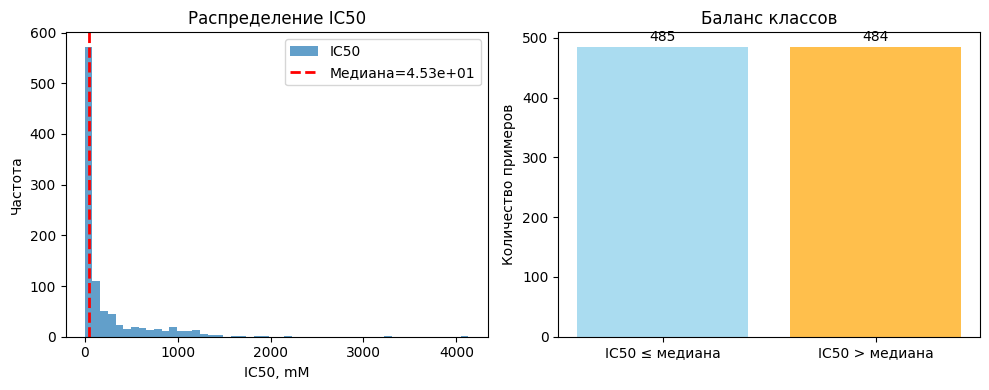

Медиана IC50: 4.5338e+01
Баланс классов:
IC50_above_median
0    0.500516
1    0.499484
Name: proportion, dtype: float64


In [39]:
import matplotlib.pyplot as plt
# Создание бинарной цели
median_ic50 = df['IC50, mM'].median()
df['IC50_above_median'] = (df['IC50, mM'] > median_ic50).astype(int)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['IC50, mM'], bins=50, alpha=0.7, label='IC50')
plt.axvline(median_ic50, color='red', linestyle='--', linewidth=2, label=f'Медиана={median_ic50:.2e}')
plt.title('Распределение IC50')
plt.xlabel('IC50, mM')
plt.ylabel('Частота')
plt.legend()

plt.subplot(1, 2, 2)
counts = df['IC50_above_median'].value_counts()
plt.bar(['IC50 ≤ медиана', 'IC50 > медиана'], counts.values, color=['skyblue', 'orange'], alpha=0.7)
plt.title('Баланс классов')
plt.ylabel('Количество примеров')
for i, v in enumerate(counts.values):
    plt.text(i, v + 10, str(v), ha='center')
plt.tight_layout()
plt.show()

print(f'Медиана IC50: {median_ic50:.4e}')
print('Баланс классов:')
print(df['IC50_above_median'].value_counts(normalize=True))

## Шаг 2: Подготовка данных для обучения моделей

### Важный момент
1) Для классификации IC50:
    - нельзя использовать CC50 и SI как признаки (так как SI зависит от IC50 и CC50);
    - бинарная целевая переменная (IC50 > медиана vs IC50 ≤ медиана);
2) Используется стратифицированная кросс-валидация для сохранения баланса классов;
3) Применяется подбор гиперпараметров через Grid/Random Search;
4) Метрики: Accuracy, Precision, Recall, F1, ROC AUC.
5) Все результаты сохраняются в папку reports/.

In [40]:
# Целевая переменная - бинарный класс IC50 > медиана
y = df['IC50_above_median']

# Признаки — всё, кроме целевых колонок
# ВАЖНО: удаляем IC50, CC50, SI, чтобы не было утечки данных!
drop_cols = ['IC50, mM', 'CC50, mM', 'SI', 'IC50_above_median']
X = df.drop(columns=drop_cols, errors='ignore')

print(f"Признаков: {X.shape[1]}")
print(f"Целевая: IC50_above_median (бинарная классификация)")
print(f"Баланс классов: {y.value_counts(normalize=True).to_dict()}")

Признаков: 210
Целевая: IC50_above_median (бинарная классификация)
Баланс классов: {0: 0.500515995872033, 1: 0.49948400412796695}


## РАЗДЕЛЕНИЕ НА ОБУЧЕНИЕ И ТЕСТ (со стратификацией)

АНАЛИЗ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ


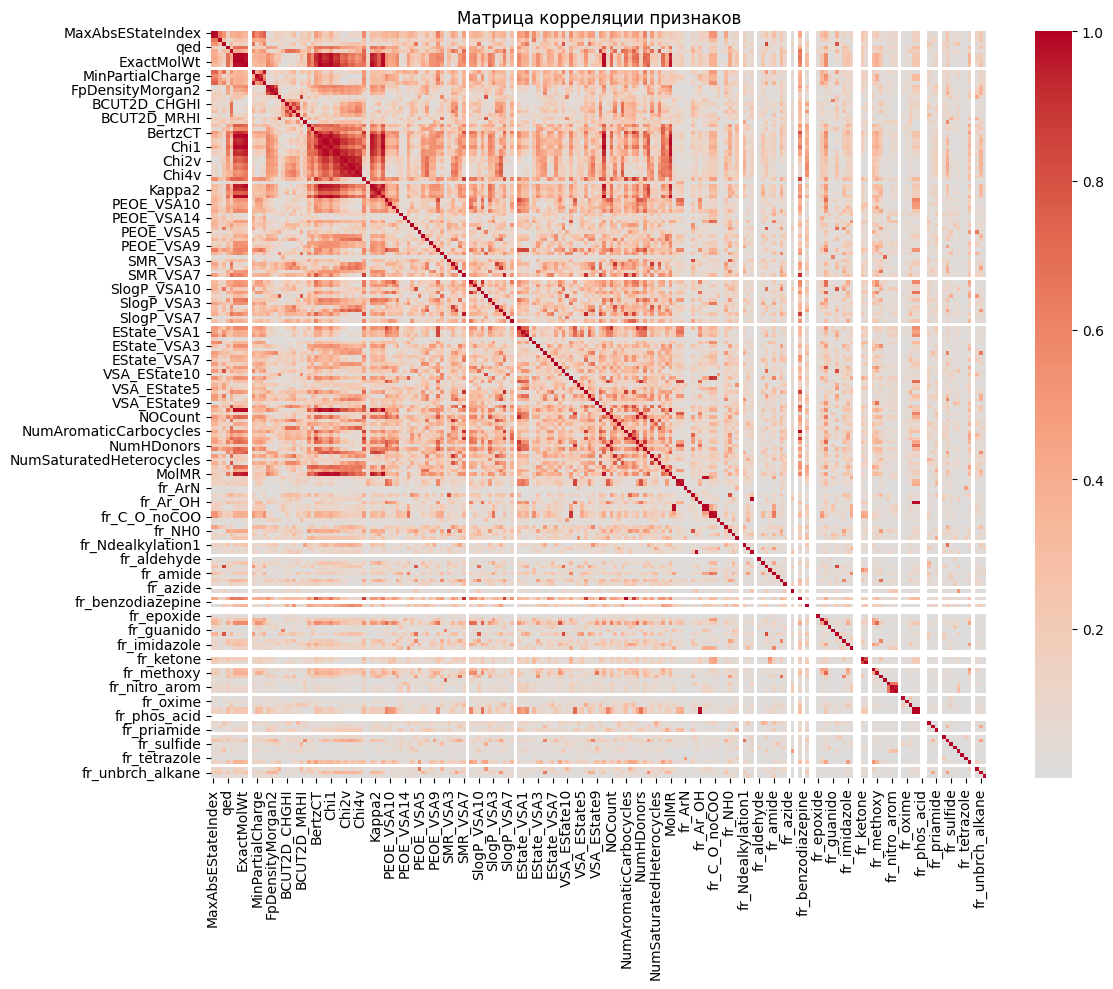

In [41]:
# Анализ и удаление высококоррелированных признаков
print("=" * 60)
print("АНАЛИЗ КОРРЕЛИРОВАННЫХ ПРИЗНАКОВ")
print("=" * 60)

# Вычисляем матрицу корреляции
X_numeric = X.select_dtypes(include=[np.number]).copy()
corr_matrix = X_numeric.corr().abs()

# Визуализируем корреляцию (heatmap)
if corr_matrix.shape[0] > 1:  # Можно визуализировать только если >1 признак
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
    plt.title('Матрица корреляции признаков')
    plt.tight_layout()
    plt.show()

In [42]:
# Находим и удаляем высококоррелированные пары (>0.95)
correlation_threshold = 0.95
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > correlation_threshold:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(f"\nОбнаружено {len(high_corr_df)} пар признаков с корреляцией > {correlation_threshold}:")
    print(high_corr_df.to_string(index=False))
    
    # Удаляем один из каждой высококоррелированной пары
    cols_to_drop = []
    for pair in high_corr_pairs:
        if pair['Feature 2'] not in cols_to_drop:
            cols_to_drop.append(pair['Feature 2'])
    
    X = X.drop(columns=cols_to_drop)
    print(f"\nУдалены {len(cols_to_drop)} признаков: {cols_to_drop}")
else:
    print(f"\nНет пар признаков с корреляцией > {correlation_threshold}")

print(f"\nОстаток признаков: {X.shape[1]}")


Обнаружено 94 пар признаков с корреляцией > 0.95:
             Feature 1              Feature 2  Correlation
     MaxAbsEStateIndex         MaxEStateIndex     1.000000
NumAromaticCarbocycles             fr_benzene     1.000000
              fr_Ar_NH           fr_Nhpyrrole     1.000000
                fr_COO                fr_COO2     1.000000
             fr_phenol fr_phenol_noOrthoHbond     1.000000
                 MolWt             ExactMolWt     0.999999
                  Chi1         HeavyAtomCount     0.998736
                 MolWt         HeavyAtomMolWt     0.996861
        HeavyAtomMolWt             ExactMolWt     0.996830
                  Chi0         HeavyAtomCount     0.995968
   NumValenceElectrons                   Chi0     0.994847
             LabuteASA         HeavyAtomCount     0.994362
                  Chi1              LabuteASA     0.992830
                 Chi0n                  Chi0v     0.992684
                  Chi0                   Chi1     0.990931
     

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")
print(f"Баланс классов в train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Баланс классов в test: {y_test.value_counts(normalize=True).to_dict()}")

Обучающая выборка: 775 строк
Тестовая выборка: 194 строк
Баланс классов в train: {0: 0.5006451612903225, 1: 0.4993548387096774}
Баланс классов в test: {0: 0.5, 1: 0.5}


## Шаг 3: Обучение моделей

In [44]:
os.makedirs('../reports', exist_ok=True) 

In [45]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(max_iter=3000, random_state=42, solver='liblinear'))
        ]),
        {'model__C': [0.05, 0.1, 1.0, 5.0], 'model__penalty': ['l1', 'l2'], 'model__class_weight': [None, 'balanced']},
        'grid'
    ),
    'RandomForest': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
        ]),
        {'model__n_estimators': [250, 400], 'model__max_depth': [None, 16], 'model__min_samples_split': [2, 5], 'model__min_samples_leaf': [1, 2], 'model__class_weight': [None, 'balanced']},
        'random'
    ),
    'GradientBoosting': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('model', GradientBoostingClassifier(random_state=42))
        ]),
        {'model__n_estimators': [100, 200], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [2, 3, 4], 'model__subsample': [0.7, 0.85]},
        'random'
    ),
    'SVC': (
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('model', SVC(random_state=42, probability=True))
        ]),
        {'model__C': [0.1, 1.0], 'model__kernel': ['linear', 'rbf']},
        'grid'
    )
}

results = []
best_model_name = ""
best_auc = -1.0

for name, (pipeline, param_grid, search_type) in models.items():
    print(f"\n=== {name} ===")
    
    if search_type == 'grid':
        search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    else:
        search = RandomizedSearchCV(pipeline, param_grid, cv=cv, scoring='roc_auc', n_iter=16, n_jobs=-1, random_state=42)
    
    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    
    print(f'Best params: {search.best_params_}')
    
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, 'predict_proba'):
        y_proba = best_model.predict_proba(X_test)[:, 1]
    else:
        y_proba = best_model.decision_function(X_test)
    
    acc = float(accuracy_score(y_test, y_pred))
    precision = float(precision_score(y_test, y_pred, zero_division=0))
    recall = float(recall_score(y_test, y_pred, zero_division=0))
    f1 = float(f1_score(y_test, y_pred, zero_division=0))
    roc_auc = float(roc_auc_score(y_test, y_proba))
    
    print(f'Accuracy: {acc:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1: {f1:.4f}')
    print(f'ROC AUC: {roc_auc:.4f}')
    print(f'CV ROC AUC: {search.best_score_:.4f}')
    print(classification_report(y_test, y_pred))
    print('Confusion matrix:\n', confusion_matrix(y_test, y_pred))
    print('-' * 40)
    
    results.append({
        'Model': name,
        'CV_ROC_AUC': float(search.best_score_),
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC_AUC': roc_auc,
        'Best_params': json.dumps(search.best_params_, ensure_ascii=False)
    })
    
    if roc_auc > best_auc:
        best_auc = roc_auc
        best_model_name = name




=== LogisticRegression ===
Best params: {'model__C': 0.05, 'model__class_weight': 'balanced', 'model__penalty': 'l2'}
Accuracy: 0.7113
Precision: 0.7113
Recall: 0.7113
F1: 0.7113
ROC AUC: 0.7715
CV ROC AUC: 0.7488
              precision    recall  f1-score   support

           0       0.71      0.71      0.71        97
           1       0.71      0.71      0.71        97

    accuracy                           0.71       194
   macro avg       0.71      0.71      0.71       194
weighted avg       0.71      0.71      0.71       194

Confusion matrix:
 [[69 28]
 [28 69]]
----------------------------------------

=== RandomForest ===
Best params: {'model__n_estimators': 250, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 16, 'model__class_weight': 'balanced'}
Accuracy: 0.7268
Precision: 0.7200
Recall: 0.7423
F1: 0.7310
ROC AUC: 0.8049
CV ROC AUC: 0.7721
              precision    recall  f1-score   support

           0       0.73      0.71      0.72 

## Шаг 4: Сравнение и сохранение результатов 

In [46]:
results_df = pd.DataFrame(results).sort_values(by='ROC_AUC', ascending=False)
print(results_df.to_string(index=False))

# Лучшая модель
best_acc = float(results_df[results_df['Model'] == best_model_name]['Accuracy'].iloc[0])
best_precision = float(results_df[results_df['Model'] == best_model_name]['Precision'].iloc[0])
best_recall = float(results_df[results_df['Model'] == best_model_name]['Recall'].iloc[0])
best_f1 = float(results_df[results_df['Model'] == best_model_name]['F1'].iloc[0])
best_roc_auc = float(results_df[results_df['Model'] == best_model_name]['ROC_AUC'].iloc[0])

print(f"\n✓ Лучшая модель: {best_model_name}")
print(f"  Accuracy: {best_acc:.4f}")
print(f"  Precision: {best_precision:.4f}")
print(f"  Recall: {best_recall:.4f}")
print(f"  F1: {best_f1:.4f}")
print(f"  ROC AUC: {best_roc_auc:.4f}")

# Сохраняем в общую таблицу классификации
summary_file = '../reports/classification_summary.csv'
task_name = 'IC50_median'

if os.path.exists(summary_file):
    summary_df = pd.read_csv(summary_file)
    summary_df = summary_df[summary_df['task'] != task_name]
else:
    summary_df = pd.DataFrame()

new_row = pd.DataFrame([{
    'task': task_name,
    'best_model': best_model_name,
    'accuracy': best_acc,
    'precision': best_precision,
    'recall': best_recall,
    'f1': best_f1,
    'roc_auc': best_roc_auc
}])

summary_df = pd.concat([summary_df, new_row], ignore_index=True)
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Результат добавлен в {summary_file}")

             Model  CV_ROC_AUC  Accuracy  Precision   Recall       F1  ROC_AUC                                                                                                                                          Best_params
      RandomForest    0.772128  0.726804   0.720000 0.742268 0.730964 0.804921 {"model__n_estimators": 250, "model__min_samples_split": 5, "model__min_samples_leaf": 2, "model__max_depth": 16, "model__class_weight": "balanced"}
  GradientBoosting    0.779421  0.706186   0.712766 0.690722 0.701571 0.794665                                           {"model__subsample": 0.85, "model__n_estimators": 100, "model__max_depth": 2, "model__learning_rate": 0.1}
               SVC    0.750216  0.711340   0.695238 0.752577 0.722772 0.790785                                                                                                            {"model__C": 1.0, "model__kernel": "rbf"}
LogisticRegression    0.748751  0.711340   0.711340 0.711340 0.711340 0.771549          